# Cloud Masking HLS (Harmonized Landsat Sentinel) Imagery

This notebook shows how to stream an HLS granule from NASA Earthdata and generate a cloud mask using OmniCloudMask.

**Extra dependencies:**
```
pip install earthaccess
```

In [1]:
from concurrent.futures import ThreadPoolExecutor

import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
from rasterio.env import Env

from omnicloudmask import predict_from_array

## 1. Authenticate with NASA Earthdata

Use `earthaccess` to open an authenticated session. A free account is required — register at [earthdata.nasa.gov](https://www.earthdata.nasa.gov/data/earthdata-login).

In [2]:
earthaccess.login(persist=True)

Request short-lived S3 credentials and configure GDAL so rasterio can stream the cloud-hosted GeoTIFFs directly without downloading them.

In [3]:
earthaccess.get_s3_credentials(daac="LPCLOUD")

env = Env(
    GDAL_HTTP_COOKIEFILE="~/cookies.txt",
    GDAL_HTTP_COOKIEJAR="~/cookies.txt",
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
    CPL_VSIL_CURL_ALLOWED_EXTENSIONS="TIF",
    GDAL_HTTP_UNSAFESSL="YES",
    GDAL_HTTP_MAX_RETRY="10",
    GDAL_HTTP_RETRY_DELAY="0.5",
)

## 2. Search for an HLS granule

Define a bounding box and temporal window, then search both the Landsat (HLSL30) and Sentinel-2 (HLSS30) HLS collections. OmniCloudMask supports both.

In [4]:
bbox = (-122.09684570249401, 39.89193960036616, -122.03465069273044, 39.92326328372664)
temporal = ("2021-05-22T00:00:00", "2021-05-23T23:59:59")

results = earthaccess.search_data(
    short_name=["HLSL30", "HLSS30"], bounding_box=bbox, temporal=temporal, count=1
)

image_links = results[0].data_links()
print(f"Found {len(image_links)} asset links")

Found 18 asset links


## 3. Load bands in parallel

OmniCloudMask expects a `(3, H, W)` array in **Red, Green, NIR** order. We also load Blue for true-colour visualisation. Band names differ between Landsat and Sentinel-2 HLS products — the code detects which sensor is present automatically.

All bands are streamed in parallel using `ThreadPoolExecutor`.

In [5]:
if ".L30." in image_links[0]:
    print("Landsat scene")
    ocm_bands = ["B04", "B03", "B05"]  # Red, Green, NIR
else:
    print("Sentinel-2 scene")
    ocm_bands = ["B04", "B03", "B8A"]  # Red, Green, NIR

rgb_bands = ["B04", "B03", "B02"]  # Red, Green, Blue for display

Sentinel-2 scene


In [6]:
def get_link(links: list[str], band: str) -> str:
    return next(link for link in links if f".{band}.tif" in link)


def read_band(link: str) -> np.ndarray:
    with rio.open(link) as src:
        return src.read(1)


with env:
    with ThreadPoolExecutor() as executor:
        ocm_futures = [
            executor.submit(read_band, get_link(image_links, b)) for b in ocm_bands
        ]
        rgb_futures = [
            executor.submit(read_band, get_link(image_links, b)) for b in rgb_bands
        ]
        ocm_arrays = [f.result() for f in ocm_futures]
        rgb_arrays = [f.result() for f in rgb_futures]

scene = np.stack(ocm_arrays)  # (3, H, W) Red, Green, NIR for OmniCloudMask
rgb = np.stack(rgb_arrays)  # (3, H, W) Red, Green, Blue for display
print(f"Scene shape: {scene.shape}")

Scene shape: (3, 3660, 3660)


## 4. Run OmniCloudMask

HLS data uses `-9999` as a nodata value — pass this so OmniCloudMask can exclude those pixels from inference.

In [7]:
mask = predict_from_array(scene, no_data_value=-9999)
print(f"Mask shape: {mask.shape}")
print("Classes — 0: clear, 1: thick cloud, 2: thin cloud, 3: cloud shadow")

Mask shape: (1, 3660, 3660)
Classes — 0: clear, 1: thick cloud, 2: thin cloud, 3: cloud shadow


## 5. Visualise

Three panels: true-colour RGB, the raw class mask, and an overlay where non-clear pixels are shown at 40% opacity.

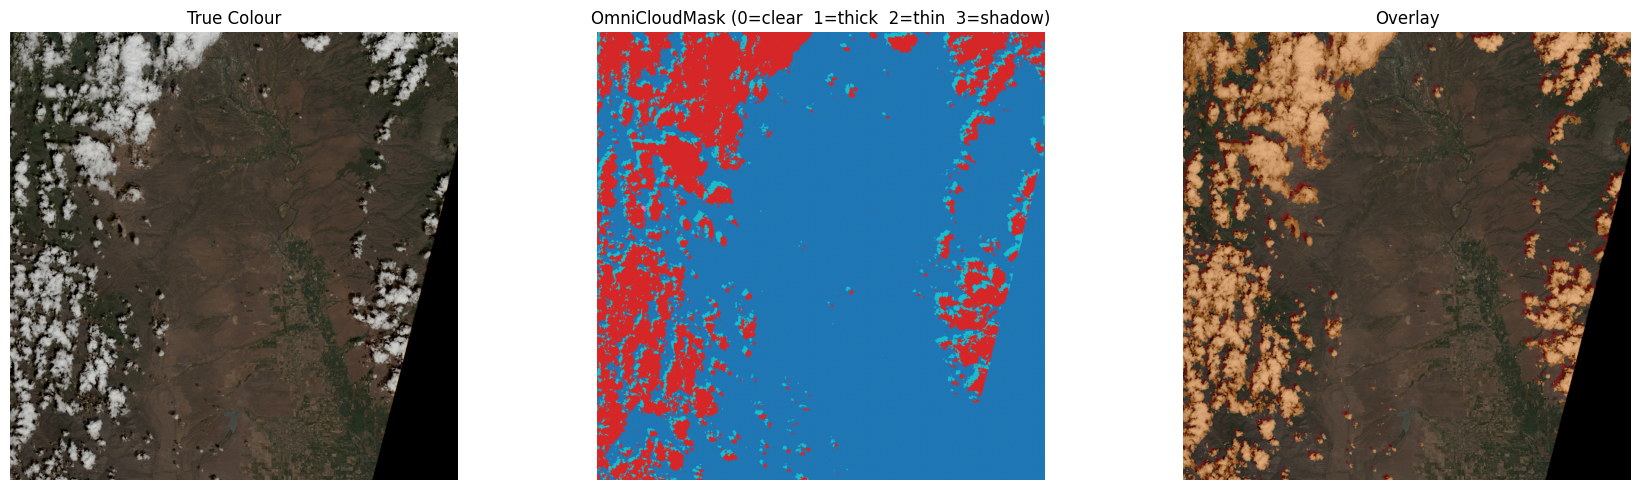

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rgb_display = np.clip(rgb.astype("float32"), 0, None)
rgb_display = np.power(rgb_display, 0.5)
rgb_display = (rgb_display - rgb_display.min()) / (
    rgb_display.max() - rgb_display.min()
)
rgb_display = np.clip(rgb_display, 0, 1).transpose(1, 2, 0)

axes[0].imshow(rgb_display)
axes[0].set_title("True Colour")
axes[0].axis("off")

axes[1].imshow(mask.squeeze(), cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

tab10 = plt.get_cmap("tab10")
mask_sq = mask.squeeze()
rgba = np.zeros((*mask_sq.shape, 4), dtype=float)
for cls in range(4):
    colour = tab10(cls / 9)
    where = mask_sq == cls
    rgba[where, :3] = colour[:3]
    rgba[where, 3] = 0.0 if cls == 0 else 0.4

axes[2].imshow(rgb_display)
axes[2].imshow(rgba)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

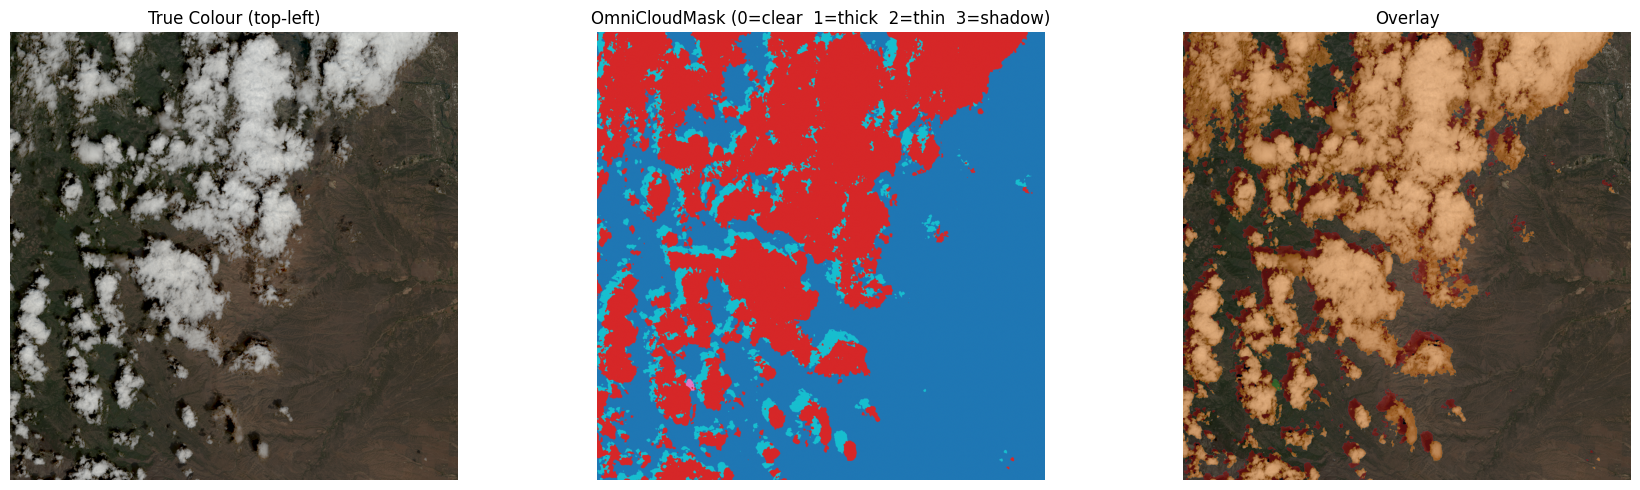

In [9]:
# Zoom into the top-left quarter
h, w = mask_sq.shape
rs, re, cs, ce = 0, h // 2, 0, w // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(rgb_display[rs:re, cs:ce])
axes[0].set_title("True Colour (top-left)")
axes[0].axis("off")
axes[1].imshow(mask_sq[rs:re, cs:ce], cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")
axes[2].imshow(rgb_display[rs:re, cs:ce])
axes[2].imshow(rgba[rs:re, cs:ce])
axes[2].set_title("Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()